In [2]:
import sys
import torch
import pennylane as qml

print("Python:", sys.version)
print("Executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("PennyLane:", qml.__version__)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Executable: c:\Users\HP\Desktop\Qintern\week5\venv_torch_test\Scripts\python.exe
PyTorch: 2.13.0+cpu
PennyLane: 0.45.1


# 04 — Stabilized QGAN retrain

This notebook trains one class-specific hybrid QGAN for each malware
family. The quantum resource convention is aligned with the shared
pipeline: 6 qubits, analytic `default.qubit`, two data-reuploading
layers, ring-CNOT entanglement, and seed 42.

Stabilization is explicit: small generator initialization, a smaller
discriminator, less-frequent discriminator updates, gradient clipping,
mean/standard-deviation regularization, early stopping, and a
**training-only** output-bias calibration. Validation chooses the
checkpoint and synthetic budget. The evaluation partition is not
scored.

In [3]:
import copy, json, os, platform, random, time
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, matthews_corrcoef

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    import pennylane as qml
except (ImportError, OSError) as exc:
    raise RuntimeError(
        "PyTorch/PennyLane could not load. Use Python 3.11 and the supplied setup."
    ) from exc

sns.set_theme(style="whitegrid")
PROFILE = os.getenv("REVALIDATION_PROFILE", "research").strip().lower()
if PROFILE not in {"smoke", "research"}:
    raise ValueError("REVALIDATION_PROFILE must be smoke or research")
REPORTABLE = PROFILE == "research"
N_QUBITS, N_COMPONENTS, N_LAYERS = 6, 8, 2
EPOCHS = 3 if PROFILE == "smoke" else 60
PATIENCE = 2 if PROFILE == "smoke" else 12
BATCH_SIZE = 32 if PROFILE == "smoke" else 64
REAL_CAP_PER_CLASS = 256 if PROFILE == "smoke" else 2_048
VALIDATION_SAMPLE = 128 if PROFILE == "smoke" else 512
BUDGETS = [0.25, 0.50, 1.00]
LR_G, LR_D = 2e-3, 5e-4
LAMBDA_MEAN, LAMBDA_STD = 10.0, 5.0
D_UPDATE_INTERVAL = 2
print({"profile": PROFILE, "reportable": REPORTABLE, "epochs": EPOCHS})

{'profile': 'research', 'reportable': True, 'epochs': 60}


In [4]:
from pathlib import Path

def resolve_project_root() -> Path:
    starts = [Path.cwd().resolve()]
    try:
        starts.append(Path(__file__).resolve().parent)
    except NameError:
        pass
    for start in starts:
        for candidate in [start, *start.parents]:
            if candidate.name == "Marco_Revalidation_v2":
                return candidate
            nested = candidate / "Marco_Revalidation_v2"
            if (nested / "00_protocol").exists():
                return nested
    raise FileNotFoundError(
        "Could not locate Marco_Revalidation_v2. Run this notebook from inside "
        "the extracted project directory."
    )

PROJECT_ROOT = resolve_project_root()
CONTRACT_DIR = PROJECT_ROOT / "01_data_contract"
CLASSICAL_DIR = PROJECT_ROOT / "02_classical_augmentation" / "outputs"
CTGAN_DIR = PROJECT_ROOT / "03_ctgan"
QGAN_DIR = PROJECT_ROOT / "04_qgan"
FIDELITY_DIR = PROJECT_ROOT / "05_fidelity"
DOWNSTREAM_DIR = PROJECT_ROOT / "06_downstream"
HANDOFF_DIR = PROJECT_ROOT / "07_quantum_handoff"
REPORT_DIR = PROJECT_ROOT / "08_reporting"
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2


In [5]:
TARGET = "Label"
CLASS_ORDER = ["Benign", "Ransomware", "Spyware", "Trojan"]
MINORITY_CLASSES = ["Ransomware", "Spyware", "Trojan"]
SEED = 42
EXPECTED_SHA256 = "cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a"

required = {
    "clean": CONTRACT_DIR / "malmem2022_clean_locked.csv.gz",
    "split": CONTRACT_DIR / "split_manifest.csv",
    "preprocessor": CONTRACT_DIR / "preprocessing.joblib",
    "arrays": CONTRACT_DIR / "locked_preprocessed_splits.npz",
    "manifest": CONTRACT_DIR / "dataset_manifest.json",
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Run Notebook 01 first. Missing:\n- " + "\n- ".join(missing))

dataset_manifest = json.loads(required["manifest"].read_text(encoding="utf-8"))
preprocessing = joblib.load(required["preprocessor"])
locked = np.load(required["arrays"])
clean = pd.read_csv(required["clean"], low_memory=False)

assert dataset_manifest["source_sha256"] == EXPECTED_SHA256
assert preprocessing["dataset_sha256"] == EXPECTED_SHA256
assert len(clean) == 58_062 and clean["row_id"].is_unique
assert clean["partition"].value_counts().to_dict() == {
    "train": 40_642, "validation": 8_710, "test": 8_710
}

retained_features = list(preprocessing["retained_features"])
X_train = locked["X_train"].astype(np.float64)
X_validation = locked["X_validation"].astype(np.float64)
X_test = locked["X_test"].astype(np.float64)
y_train = locked["y_train"].astype(str)
y_validation = locked["y_validation"].astype(str)
y_test = locked["y_test"].astype(str)
assert X_train.shape == (40_642, 52)
assert X_validation.shape == (8_710, 52)
assert X_test.shape == (8_710, 52)
assert np.isfinite(X_train).all() and np.isfinite(X_validation).all() and np.isfinite(X_test).all()
print("Locked contract verified:", X_train.shape, X_validation.shape, X_test.shape)

Locked contract verified: (40642, 52) (8710, 52) (8710, 52)


## 1. Frozen train-only PCA representation

The QGAN operates in eight PCA components. PCA is fitted only on the
locked real training matrix, then frozen for validation and generation.
The downstream classifier still receives all 52 reconstructed scaled
features.

In [6]:
OUTPUT_DIR = QGAN_DIR / "outputs"
CHECKPOINT_DIR = QGAN_DIR / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
for name in ["matched", "multiclass_budget", "selected"]:
    (OUTPUT_DIR / name).mkdir(exist_ok=True)

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

seed_everything(SEED)
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
Z_train = pca.fit_transform(X_train)
Z_validation = pca.transform(X_validation)
Z_test = pca.transform(X_test)  # transformed only; labels are not scored
joblib.dump(pca, OUTPUT_DIR / "qgan_train_only_pca.joblib")
print("Explained variance (8 components):", pca.explained_variance_ratio_.sum())

scaled_low = np.quantile(X_train, 0.001, axis=0)
scaled_high = np.quantile(X_train, 0.999, axis=0)

Explained variance (8 components): 0.845771129344228


## 2. Six-qubit data-reuploading generator and compact discriminator

In [7]:
dev = qml.device("default.qubit", wires=N_QUBITS, shots=None)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    for layer in range(N_LAYERS):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
        for wire in range(N_QUBITS):
            qml.RY(weights[layer, wire, 0], wires=wire)
            qml.RZ(weights[layer, wire, 1], wires=wire)
        for wire in range(N_QUBITS):
            qml.CNOT(wires=[wire, (wire + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(wire)) for wire in range(N_QUBITS)]

class HybridQuantumGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.angle_map = nn.Linear(N_QUBITS, N_QUBITS)
        self.quantum = qml.qnn.TorchLayer(
            quantum_circuit,
            {"weights": (N_LAYERS, N_QUBITS, 2)},
        )
        self.head = nn.Linear(N_QUBITS, N_COMPONENTS)
        self.register_buffer("output_bias", torch.zeros(N_COMPONENTS))
        for parameter in self.parameters():
            nn.init.normal_(parameter, mean=0.0, std=0.01)

    def forward(self, noise, calibrated=True):
        angles = torch.pi * torch.tanh(self.angle_map(noise))
        quantum_values = self.quantum(angles).to(dtype=self.head.weight.dtype)
        values = self.head(quantum_values)
        return values + self.output_bias if calibrated else values

class CompactDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(N_COMPONENTS, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 16), nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
        )
    def forward(self, values):
        return self.network(values).squeeze(-1)

bce = nn.BCEWithLogitsLoss()

@torch.no_grad()
def generate_latent(generator, n, seed, calibrated=True, batch_size=256):
    cpu_state = torch.random.get_rng_state()
    torch.manual_seed(seed)
    generator.eval()
    pieces = []
    while sum(len(x) for x in pieces) < n:
        current = min(batch_size, n - sum(len(x) for x in pieces))
        noise = torch.randn(current, N_QUBITS)
        pieces.append(generator(noise, calibrated=calibrated).cpu().numpy())
    torch.random.set_rng_state(cpu_state)
    return np.vstack(pieces)[:n]

def validation_moment_score(real_validation, synthetic):
    mean_gap = float(np.mean(np.abs(real_validation.mean(0) - synthetic.mean(0))))
    std_gap = float(np.mean(np.abs(real_validation.std(0) - synthetic.std(0))))
    real_div = float(np.mean(np.std(real_validation, axis=0)))
    syn_div = float(np.mean(np.std(synthetic, axis=0)))
    diversity_ratio = syn_div / max(real_div, 1e-12)
    return mean_gap + std_gap + abs(diversity_ratio - 1.0), mean_gap, std_gap, diversity_ratio

## 3. Class-specific stabilized training

The deterministic class cap is a declared quantum-resource control, not
a hidden row cap. It is applied only to QGAN optimization; validation
and generated budget counts retain their protocol-defined sizes.

In [8]:
def train_one_class(class_name, class_index):
    seed = SEED + 100 * class_index
    seed_everything(seed)
    real_all = Z_train[y_train == class_name]
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(real_all), size=min(REAL_CAP_PER_CLASS, len(real_all)), replace=False)
    real_fit = real_all[chosen].astype(np.float32)
    real_validation = Z_validation[y_validation == class_name]

    generator = HybridQuantumGenerator()
    discriminator = CompactDiscriminator()
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.9))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.9))
    target_mean = torch.tensor(real_fit.mean(0), dtype=torch.float32)
    target_std = torch.tensor(real_fit.std(0), dtype=torch.float32)
    loader = DataLoader(
        TensorDataset(torch.tensor(real_fit)), batch_size=BATCH_SIZE,
        shuffle=True, drop_last=True,
        generator=torch.Generator().manual_seed(seed),
    )

    history, best_state, best_score = [], None, np.inf
    stale, global_step = 0, 0
    for epoch in range(1, EPOCHS + 1):
        stats = {k: [] for k in ["d_loss", "g_loss", "d_real", "d_fake", "grad_norm"]}
        for (real_batch,) in loader:
            batch_n = len(real_batch)
            noise = torch.randn(batch_n, N_QUBITS)
            fake_batch = generator(noise, calibrated=False)

            if global_step % D_UPDATE_INTERVAL == 0:
                d_real_logits = discriminator(real_batch)
                d_fake_logits = discriminator(fake_batch.detach())
                d_loss = bce(d_real_logits, torch.ones_like(d_real_logits)) + bce(
                    d_fake_logits, torch.zeros_like(d_fake_logits)
                )
                optimizer_d.zero_grad(set_to_none=True); d_loss.backward()
                torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
                optimizer_d.step()
            else:
                with torch.no_grad():
                    d_real_logits = discriminator(real_batch)
                    d_fake_logits = discriminator(fake_batch.detach())
                    d_loss = bce(d_real_logits, torch.ones_like(d_real_logits)) + bce(
                        d_fake_logits, torch.zeros_like(d_fake_logits)
                    )

            g_logits = discriminator(fake_batch)
            adversarial = bce(g_logits, torch.ones_like(g_logits))
            mean_loss = torch.mean((fake_batch.mean(0) - target_mean) ** 2)
            std_loss = torch.mean((fake_batch.std(0, unbiased=False) - target_std) ** 2)
            g_loss = adversarial + LAMBDA_MEAN * mean_loss + LAMBDA_STD * std_loss
            optimizer_g.zero_grad(set_to_none=True); g_loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
            optimizer_g.step()

            stats["d_loss"].append(float(d_loss.detach()))
            stats["g_loss"].append(float(g_loss.detach()))
            stats["d_real"].append(float(torch.sigmoid(d_real_logits).mean().detach()))
            stats["d_fake"].append(float(torch.sigmoid(d_fake_logits).mean().detach()))
            stats["grad_norm"].append(float(grad_norm))
            global_step += 1

        eval_n = min(VALIDATION_SAMPLE, len(real_validation))
        synthetic_eval = generate_latent(
            generator, eval_n, seed + 10_000 + epoch, calibrated=False
        )
        score, mean_gap, std_gap, ratio = validation_moment_score(
            real_validation[:eval_n], synthetic_eval
        )
        row = {"class": class_name, "epoch": epoch,
               **{k: float(np.mean(v)) for k, v in stats.items()},
               "validation_selection_score": score,
               "validation_mean_gap": mean_gap,
               "validation_std_gap": std_gap,
               "validation_diversity_ratio": ratio}
        history.append(row)
        if score < best_score - 1e-5:
            best_score = score
            best_state = copy.deepcopy(generator.state_dict())
            stale = 0
        else:
            stale += 1
        print(class_name, epoch, "score", round(score, 4), "G", round(row["g_loss"], 4))
        if stale >= PATIENCE:
            print("Early stopping", class_name, "at", epoch)
            break

    if best_state is None:
        raise RuntimeError("No QGAN checkpoint was selected")
    generator.load_state_dict(best_state)

    # Training-only output-bias calibration. Validation/test are excluded.
    calibration_n = min(4096, max(1024, len(real_fit)))
    uncalibrated = generate_latent(
        generator, calibration_n, seed + 80_000, calibrated=False
    )
    bias = real_fit.mean(0) - uncalibrated.mean(0)
    generator.output_bias.copy_(torch.tensor(bias, dtype=torch.float32))
    checkpoint = CHECKPOINT_DIR / f"qgan_{class_name.lower()}_selected.pt"
    torch.save({
        "state_dict": generator.state_dict(), "class": class_name,
        "seed": seed, "config": {"qubits": N_QUBITS, "layers": N_LAYERS,
        "components": N_COMPONENTS, "shots": None},
        "training_only_output_bias": bias.tolist(),
        "best_validation_score": best_score,
    }, checkpoint)
    return generator, pd.DataFrame(history), bias, best_score

generators, history_frames, calibration_rows = {}, [], []
for index, class_name in enumerate(MINORITY_CLASSES):
    generator, history, bias, best_score = train_one_class(class_name, index)
    generators[class_name] = generator
    history_frames.append(history)
    calibration_rows.append({
        "class": class_name, "best_validation_score": best_score,
        **{f"bias_pc{i+1}": float(value) for i, value in enumerate(bias)},
    })
history = pd.concat(history_frames, ignore_index=True)
history.to_csv(OUTPUT_DIR / "qgan_training_history.csv", index=False)
pd.DataFrame(calibration_rows).to_csv(OUTPUT_DIR / "output_bias_calibration.csv", index=False)

Ransomware 1 score 3.9985 G 45.7318
Ransomware 2 score 3.7553 G 39.3917
Ransomware 3 score 3.463 G 33.9719
Ransomware 4 score 3.2244 G 29.4348
Ransomware 5 score 2.9147 G 25.6061
Ransomware 6 score 2.6946 G 21.9939
Ransomware 7 score 2.5379 G 18.8292
Ransomware 8 score 2.3504 G 16.0063
Ransomware 9 score 2.1751 G 13.6909
Ransomware 10 score 2.0461 G 11.7423
Ransomware 11 score 1.8731 G 9.6505
Ransomware 12 score 1.7773 G 8.3886
Ransomware 13 score 1.6927 G 6.9891
Ransomware 14 score 1.5681 G 6.5202
Ransomware 15 score 1.4741 G 5.4934
Ransomware 16 score 1.3626 G 4.8464
Ransomware 17 score 1.4507 G 4.9669
Ransomware 18 score 1.3459 G 5.1442
Ransomware 19 score 1.337 G 4.8949
Ransomware 20 score 1.2249 G 4.9255
Ransomware 21 score 1.125 G 4.6856
Ransomware 22 score 1.2461 G 4.8888
Ransomware 23 score 1.1877 G 4.9581
Ransomware 24 score 1.0867 G 5.1348
Ransomware 25 score 1.1618 G 5.306
Ransomware 26 score 1.2146 G 5.5626
Ransomware 27 score 1.2808 G 6.6777
Ransomware 28 score 1.2852 G 6.

## 4. Generate, reconstruct, constrain, and select a budget

In [9]:
train_counts = pd.Series(y_train).value_counts().reindex(CLASS_ORDER)
majority_count = int(train_counts.max())
full_additions = {c: majority_count - int(train_counts[c]) for c in MINORITY_CLASSES}
max_pools = {}
for index, class_name in enumerate(MINORITY_CLASSES):
    latent = generate_latent(
        generators[class_name], full_additions[class_name],
        SEED + 200_000 + index, calibrated=True,
    )
    raw_scaled = pca.inverse_transform(latent)
    constrained_scaled = np.clip(raw_scaled, scaled_low, scaled_high)
    max_pools[class_name] = {
        "latent": latent, "raw_scaled": raw_scaled,
        "constrained_scaled": constrained_scaled,
    }

def arrays_for_budget(budget):
    X_parts, y_parts = [], []
    for class_name in MINORITY_CLASSES:
        n = int(np.rint(budget * full_additions[class_name]))
        X_parts.append(max_pools[class_name]["constrained_scaled"][:n])
        y_parts.extend([class_name] * n)
    return np.vstack(X_parts), np.asarray(y_parts, str)

def save_npz(path, X_syn, y_syn):
    np.savez_compressed(
        path, X_synthetic=X_syn.astype(np.float32),
        y_synthetic=y_syn.astype(str),
        retained_features=np.asarray(retained_features, str),
        method=np.asarray(["QGAN stabilized"], str),
    )

budget_arrays = {}
for budget in BUDGETS:
    pct = int(100 * budget)
    X_syn, y_syn = arrays_for_budget(budget)
    budget_arrays[budget] = (X_syn, y_syn)
    save_npz(
        OUTPUT_DIR / "multiclass_budget" / f"qgan_budget_{pct:03d}_synthetic_scaled.npz",
        X_syn, y_syn,
    )

X_trojan = max_pools["Trojan"]["constrained_scaled"][:2000]
y_trojan = np.repeat("Trojan", len(X_trojan))
save_npz(OUTPUT_DIR / "matched" / "matched_qgan_synthetic_scaled.npz", X_trojan, y_trojan)

validation_rows = []
for budget, (X_syn, y_syn) in budget_arrays.items():
    instrument = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=-1)
    instrument.fit(np.vstack([X_train, X_syn]), np.concatenate([y_train, y_syn]))
    pred = instrument.predict(X_validation)
    validation_rows.append({
        "budget": budget, "synthetic_rows": len(X_syn),
        "validation_macro_f1": f1_score(y_validation, pred, average="macro", zero_division=0),
        "validation_mcc": matthews_corrcoef(y_validation, pred),
    })
validation_results = pd.DataFrame(validation_rows).sort_values(
    ["validation_macro_f1", "budget"], ascending=[False, True]
).reset_index(drop=True)
validation_results.to_csv(OUTPUT_DIR / "validation_budget_selection.csv", index=False)
selected_budget = float(validation_results.iloc[0]["budget"])
X_selected, y_selected = budget_arrays[selected_budget]
save_npz(OUTPUT_DIR / "selected" / "selected_qgan_synthetic_scaled.npz", X_selected, y_selected)

# Original-space constrained export for auditability.
feature_columns = list(preprocessing["feature_columns"])
retained_mask = np.asarray(preprocessing["retained_mask"], bool)
raw_train = clean.loc[clean.partition.eq("train"), feature_columns].apply(pd.to_numeric)
low, high = raw_train.min().to_numpy(float), raw_train.max().to_numpy(float)
retained_imputed = preprocessing["scaler"].inverse_transform(X_selected)
full = np.tile(preprocessing["imputer"].statistics_, (len(X_selected), 1))
full[:, retained_mask] = retained_imputed
full = np.clip(full, low, high)
constrained_frame = pd.DataFrame(full, columns=feature_columns)
constrained_frame.insert(0, TARGET, y_selected)
constrained_frame.to_csv(
    OUTPUT_DIR / "selected" / "selected_qgan_synthetic_constrained.csv.gz",
    index=False, compression="gzip",
)
display(validation_results)
print("Selected QGAN budget:", selected_budget)
print("TEST LABELS ACCESSED FOR SCORING: False")

,budget,synthetic_rows,validation_macro_f1,validation_mcc
0,0.50,20602,0.806811,0.807661
1,0.25,10301,0.804394,0.805242
2,1.00,41202,0.803085,0.803859


Selected QGAN budget: 0.5
TEST LABELS ACCESSED FOR SCORING: False


## 5. Training diagnostics and acceptance manifest

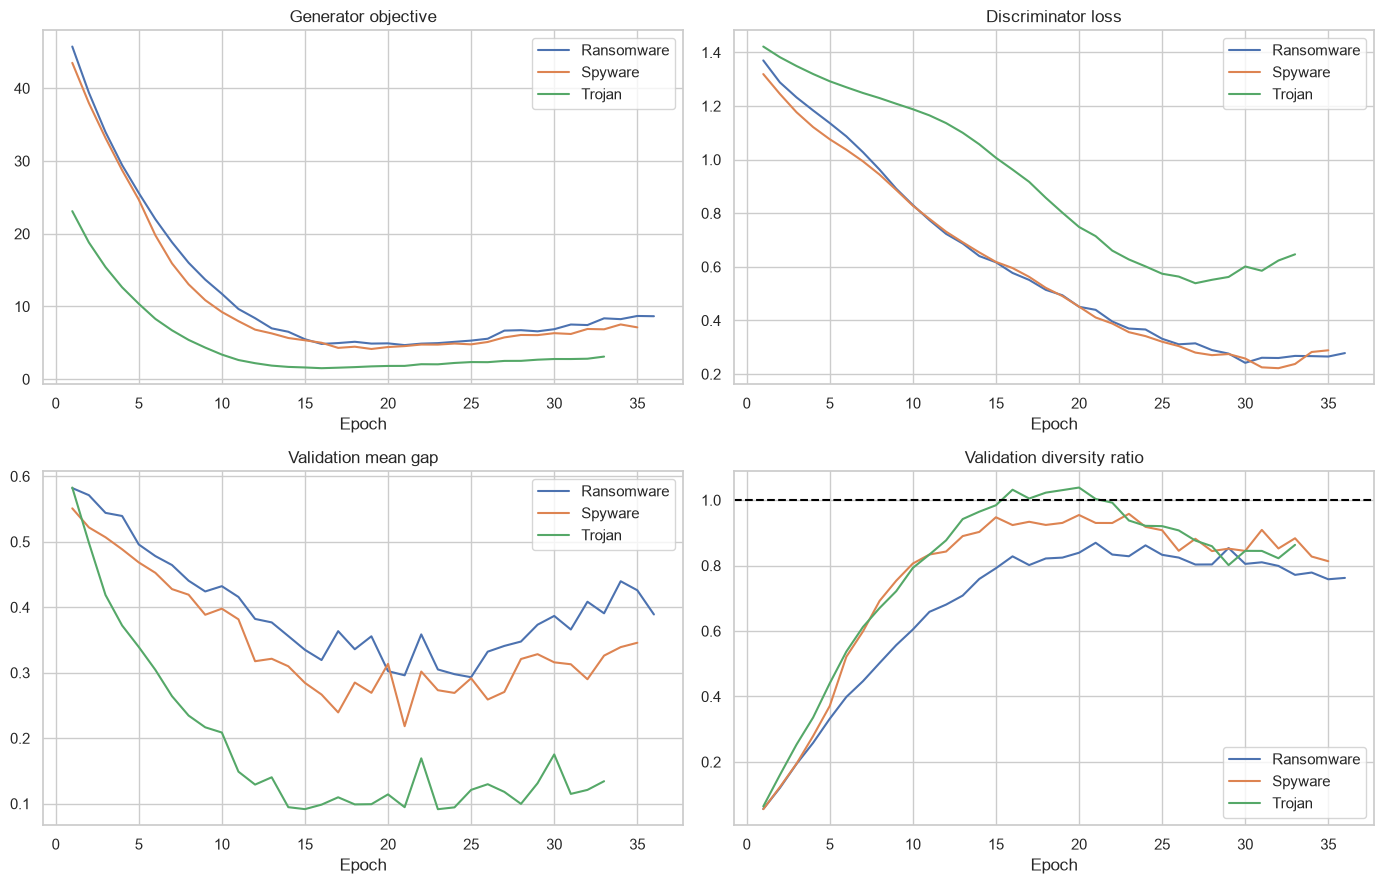

QGAN STAGE ACCEPTED


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for class_name, group in history.groupby("class"):
    axes[0,0].plot(group.epoch, group.g_loss, label=class_name)
    axes[0,1].plot(group.epoch, group.d_loss, label=class_name)
    axes[1,0].plot(group.epoch, group.validation_mean_gap, label=class_name)
    axes[1,1].plot(group.epoch, group.validation_diversity_ratio, label=class_name)
for ax, title in zip(axes.flat, ["Generator objective", "Discriminator loss",
                                "Validation mean gap", "Validation diversity ratio"]):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
axes[1,1].axhline(1.0, color="black", linestyle="--")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "01_qgan_training_diagnostics.png", dpi=180); plt.show()

unique_fraction = len(np.unique(np.round(X_selected, 10), axis=0)) / len(X_selected)
clipped_fraction = float(np.mean((X_selected <= scaled_low + 1e-12) |
                                 (X_selected >= scaled_high - 1e-12)))
assert np.isfinite(X_selected).all()
assert unique_fraction > 0.98
if history.grad_norm.max() <= 0:
    raise RuntimeError("All QGAN gradient norms are zero")

manifest = {
    "protocol_version": "revalidation_v2_qgan_stabilized_v1",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "profile": PROFILE, "reportable": REPORTABLE,
    "dataset_sha256": EXPECTED_SHA256,
    "resource_convention": {
        "qubits": N_QUBITS, "pca_components": N_COMPONENTS,
        "data_reupload_layers": N_LAYERS, "entanglement": "1D ring CNOT",
        "backend": "PennyLane default.qubit", "shots": None, "seed": SEED,
    },
    "training": {
        "epochs_max": EPOCHS, "early_stopping_patience": PATIENCE,
        "real_cap_per_class_declared": REAL_CAP_PER_CLASS,
        "generator_lr": LR_G, "discriminator_lr": LR_D,
        "discriminator_update_interval": D_UPDATE_INTERVAL,
        "lambda_mean": LAMBDA_MEAN, "lambda_std": LAMBDA_STD,
        "label_smoothing": False, "gradient_clip_norm": 1.0,
        "small_initialization_std": 0.01,
    },
    "output_bias_calibration": "training-only class mean minus uncalibrated synthetic mean",
    "selected_budget": selected_budget,
    "selected_synthetic_counts": Counter(y_selected),
    "selected_unique_fraction_rounded_10dp": unique_fraction,
    "scaled_clipped_cell_fraction": clipped_fraction,
    "validation_checkpoint_selection": True,
    "test_scored": False,
    "software": {"python": platform.python_version(), "torch": torch.__version__,
                 "pennylane": qml.__version__},
    "limitations": [
        "QGAN optimization uses a declared deterministic real-row cap per class.",
        "Analytic simulation is not hardware execution.",
        "Twelve feature-equivalent groups cross the locked comparability split.",
    ],
}
manifest["selected_synthetic_counts"] = dict(manifest["selected_synthetic_counts"])
(OUTPUT_DIR / "qgan_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
(OUTPUT_DIR / "README.md").write_text(
    f"# QGAN output\n\nProfile: {PROFILE}; reportable: {REPORTABLE}.\n"
    f"Selected budget: {selected_budget:.0%}. Test scoring: false.\n",
    encoding="utf-8",
)
print("QGAN STAGE ACCEPTED")